# Classifying Subtitle Data

Script for classifying subtitle data using regex and keyword matching.  

In [2]:
# imports 
import pandas as pd
import re
from tqdm import tqdm

In [3]:
df = pd.read_csv("parsed_and_cleaned_subtitles.csv")

In [4]:
keywords = (
    "kunstmatige intelligentie|artificial intelligence|artificiële intelligentie|AI|generatieve AI|"
    "generatieve kunstmatige intelligentie|generatieve artificiële intelligentie|"
    "machine learning|machinaal leren|diep leren|deep learning|neurale netwerken|"
    "large language model|grote taalmodel*|LLM|chatbot*|GPT|ChatGPT|Bard|Claude|"
    "Gemini|mistral|perplexity|ollama|LLaMA|openai|anthropic|midjourney|hugging face|"
    "slimme algoritme*|automatische besluitvorming|automatisch beslissysteem|"
    "algoritmische besluitvorming|algoritme*|cognitieve technologie*|AI-technologie*|"
    "AI-systeem*|AI-toepassing*|AI-model*|spraakherkenning|beeldherkenning|"
    "computer vision|natuurlijke taalverwerking|natural language processing|NLP|robot|drones|drone|grok|xai|deepmind|azure"
)

_COMPANY_NAMES = [
    "NVIDIA", "Apple", "Microsoft", "Google", "Alphabet",
    "Meta Platforms", "Facebook", "Tesla", "Oracle",
    "Palantir", "IBM", "Adobe", "Cambricon Technologies",
    "CoreWeave", "Fermi Inc", "Dynatrace", "Tempus AI",
    "SenseTime", "Mobileye", "Aurora Innovation", "UiPath",
    "SoundHound AI", "ASML", "NXP Semiconductors",
    "BE Semiconductor Industries", "ASM International",
    "Adyen", "Just Eat Takeaway", "Booking.com", "Mollie",
    "Picnic", "TomTom", "Swapfiets", "TKH Group",
    "Ordina", "Nedap", "CM.com", "ICT Group",
    "Neways Electronics", "Ctac", "Photon Energy",
    "Almunda Professionals", "Samsung", "Huawei",
    "Sony", "LG", "Baidu", "Tencent",
    "Alibaba", "Douyin", "Cloudflare",
    "Snowflake", "Docker", "Red Hat",
    "Uber", "Bolt", "Grab", "Epic Games",
    "Unity", "Discord", "Twitter", "X"
]

def normalize_keyword(k: str) -> str:
    """Convert wildcard-like keywords into safe, precise regex patterns."""

    k = k.strip().lower()

    # algoritme → algoritme, algoritmen, algoritmes
    if k in {"algoritme", "algoritme*"}:
        return r"algoritm(?:e|en|es)"

    # chatbots
    if k in {"chatbot", "chatbot*"}:
        return r"chatbots?"

    # llm / llms
    if k in {"llm", "llm*"}:
        return r"llms?"

    # grote taalmodel / grote taalmodels
    if k in {"grote taalmodel*"}:
        return r"grote taalmodel(?:s)?"

    # intelligent(e) algoritme(n)
    if "intelligente algoritme" in k:
        return r"intelligent[e]?\s+algoritm(?:e|en|es)?"

    # slimme algoritme(n)
    if "slimme algoritme" in k:
        return r"slimm[e]?\s+algoritm(?:e|en|es)?"

    # ANY OTHER keyword with a trailing "*" should become:
    #   <base> → <base>(?:s)?  
    # But only if safe.
    if k.endswith("*"):
        base = k[:-1]
        # optional plural “s”
        return re.escape(base) + r"s?"

    return re.escape(k)

# Convert into list
keywords = keywords.strip().split('|')
set_ai_words = {k for k in keywords if k.strip()}

_AI_PAT = re.compile(
    r"\b(" + "|".join(normalize_keyword(k) for k in set_ai_words) + r")\b",
    re.IGNORECASE
)

# Weiwei filter
_WEIWEI_PAT = re.compile(r'\bweiwei\b', re.IGNORECASE)

# Pattern that detects the combined form "kunstmatige intelligentie (AI)" ---
_KI_AI_PAT = re.compile(r'kunstmatige\s+intelligentie\s*\(\s*ai\s*\)', re.IGNORECASE)

def _collapse_ki_ai(matches: list[str], text: str) -> list[str]:
    """
    If the text contains 'kunstmatige intelligentie (AI)', remove up to that many 'AI'
    occurrences from the match list so the pair counts as ONE hit.
    """
    n_pairs = len(_KI_AI_PAT.findall(text))
    if n_pairs == 0:
        return matches
    kept, removed = [], 0
    for m in matches:
        if m.lower() == "ai" and removed < n_pairs:
            removed += 1         # drop this 'AI' because it's part of the pair
        else:
            kept.append(m)
    return kept

# --- Remove weiwei articles before classifying ---
def _drop_weiwei_rows(df, title_col='title', body_col='text'):
    mask = (
        df[title_col].astype(str).str.contains(_WEIWEI_PAT, na=False) |
        df[body_col].astype(str).str.contains(_WEIWEI_PAT, na=False)
    )
    removed = mask.sum()
    # print(f"Removed {removed} articles containing 'weiwei'.")
    return df.loc[~mask].copy()

_COMPANY_PAT = re.compile(
    r'\b(' + '|'.join(re.escape(n) for n in _COMPANY_NAMES) + r')\b',
    re.IGNORECASE
)
_COMPANY_TOKENS = {n.lower() for n in _COMPANY_NAMES}  # to compare against matched keyword tokens

# --- 3) Classification ---
def ai_classification(df, title_col='title', body_col='text'):

    # hard remove weiwei articles
    df = _drop_weiwei_rows(df, title_col, body_col)

    labels, matched_title, matched_body, matched_all = [], [], [], []
    n_hits_title_total, n_hits_body_total = [], []
    matched_companies_all = [] #store company hits (per row)

    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        title = row[title_col] if pd.notna(row[title_col]) else ""
        body  = row[body_col]  if pd.notna(row[body_col])  else ""
        
        # --- collect company hits from raw text (title + body)
        comp_title = _COMPANY_PAT.findall(str(title))
        comp_body  = _COMPANY_PAT.findall(str(body))
        company_hits = sorted(set(m.lower() for m in (comp_title + comp_body)))
        matched_companies_all.append(company_hits)

        # regex matches
        title_matches = _AI_PAT.findall(str(title))
        body_matches  = _AI_PAT.findall(str(body))

        # --- collapse KI (AI) double-counts ---
        title_matches = _collapse_ki_ai(title_matches, title)
        body_matches  = _collapse_ki_ai(body_matches, body)

        # ---  ignore 'claude' if it's the ONLY match across title+body ---
        all_lower = [m.lower() for m in (title_matches + body_matches)]
        if set(all_lower) == {"claude"}:
            title_matches, body_matches = [], []
            all_lower = []

        # decision rule
        title_match = len(title_matches) >= 1
        body_match  = len(body_matches)  >= 2
        label = "yes" if (title_match or body_match) else "no"

        # --- company mention + at least one other keyword -> ai_related = yes ---
        company_present = bool(company_hits)
        other_hits = [m for m in all_lower if m not in _COMPANY_TOKENS]
        if company_present and len(other_hits) >= 1:
            label = "yes"

        labels.append(label)
        matched_title.append(sorted(set(m.lower() for m in title_matches)))
        matched_body.append(sorted(set(m.lower() for m in body_matches)))
        matched_all.append(sorted(set(m.lower() for m in (title_matches + body_matches))))
        n_hits_title_total.append(len(title_matches))
        n_hits_body_total.append(len(body_matches))

    # write back
    df['ai_related'] = labels
    df['matched_keywords_title'] = matched_title
    df['matched_keywords_body']  = matched_body
    df['matched_keywords_all']   = matched_all
    df['n_hits_title_total'] = n_hits_title_total
    df['n_hits_body_total']  = n_hits_body_total
    df['company_hits'] = matched_companies_all

    return df


In [5]:
# Apply classification
classified_df = ai_classification(df, title_col='program', body_col='text_clean')

100%|██████████| 9999/9999 [01:10<00:00, 142.32it/s]


In [6]:
classified_df['ai_related'].value_counts()

ai_related
no     9451
yes     548
Name: count, dtype: int64

In [7]:
ai_related = classified_df[classified_df['ai_related'] == 'yes']


In [8]:
ai_related = ai_related.drop(ai_related.columns[0], axis =1)

In [9]:
ai_related

,filename,program,year,text_clean,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
47,"2016-11-16-19,00-1",DE WERELD DRAAIT DOOR,2016,"Eelco Bosch van Rosenthal, Dirk Jan Roeleven, ...",yes,[],[algoritme],[algoritme],0,1,"[facebook, google, twitter]"
52,"2016-02-08-23,04-1",JINEK,2016,Uitzending bijwonen? Dat kan. Ga naar jinek.kr...,yes,[],[drones],[drones],0,2,[]
56,GOEDEMORGEN_N-WON02434179,Goedemorgen Nederland,2023,en Joodse scholen die hun deuren vandaag dicht...,yes,[],"[ai, kunstmatige intelligentie]","[ai, kunstmatige intelligentie]",0,5,[]
74,GOEDEMORGEN_N-WON02298553,Goedemorgen Nederland,2022,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,[],[kunstmatige intelligentie],[kunstmatige intelligentie],0,1,[twitter]
99,GOEDEMORGEN_N-WON01991187,Goedemorgen Nederland,2019,"Goedemorgen Nederland, het is vandaag vrijdag ...",yes,[],"[drone, kunstmatige intelligentie]","[drone, kunstmatige intelligentie]",0,3,[]
...,...,...,...,...,...,...,...,...,...,...,...
9928,"2017-09-18-19,01-1",DE WERELD DRAAIT DOOR,2017,"888\nGeerte Piening, Bahar Goodarzi, Jeroen Wo...",yes,[],[robot],[robot],0,2,"[facebook, twitter]"
9936,GOEDEMORGEN_N-WON02358587,Goedemorgen Nederland,2022,"888\nGoedemorgen Nederland, welkom terug bij W...",yes,[],"[drone, drones]","[drone, drones]",0,4,[]
9941,"2018-04-27-08,38-1",Goedemorgen Nederland,2018,"888\nGoedemorgen Nederland, het is vandaag vri...",yes,[],[drones],[drones],0,1,[twitter]
9946,GOEDEMORGEN_N-WON02320372,Goedemorgen Nederland,2022,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,[],"[ai, drones]","[ai, drones]",0,3,[]


In [10]:
# make all program names lowercase for easier grouping
ai_related['program'] = ai_related['program'].str.lower()
df['program'] = df['program'].str.lower()

In [11]:
df['year'].value_counts()

year
2020    1296
2021    1287
2023    1218
2022    1191
2017    1135
2016     970
2018     925
2019     851
2015     680
2025     263
2024     184
Name: count, dtype: int64

In [46]:
ai_related['year'].value_counts()

year
2023    70
2025    66
2022    59
2020    54
2016    53
2019    52
2018    48
2017    48
2015    41
2024    31
2021    26
Name: count, dtype: int64

## Visual Analysis

Plotting value counts per year to see trends in subtitle types over time.

Plotting AI-related Subtitles as % of Total per Program to identify which programs focus more on AI topics.

Plotting AI-related Subtitles as % of Total per Year to see how AI coverage has evolved over time.

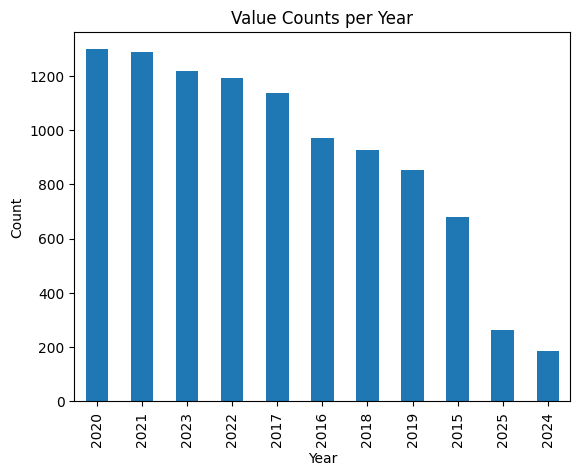

In [12]:
# plot value counts per year
import matplotlib.pyplot as plt
# sort by year (index) rather than count
df['year'].value_counts().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Value Counts per Year')
plt.show()

In [14]:
total_counts = df['program'].value_counts()
print("Total articles per program:")
print(total_counts)

Total articles per program:
program
goedemorgen nederland    7920
de wereld draait door     799
pauw                      445
jinek                     298
eva                       203
bar laat                  150
de vooravond              103
café kockelmann            59
m                          23
Name: count, dtype: int64


In [17]:
ai_counts = ai_related['program'].value_counts()
print("\nAI-related articles per program:"
      )
print(ai_counts)


AI-related articles per program:
program
goedemorgen nederland    311
de wereld draait door     87
eva                       49
pauw                      25
bar laat                  25
jinek                     24
café kockelmann           15
de vooravond               8
m                          4
Name: count, dtype: int64


In [16]:
total = df.shape[0]
print(total)

related = ai_related.shape[0]
print(related)
print("Perentage of AI-related articles:")
print(related / total * 100)

10000
548
Perentage of AI-related articles:
5.48


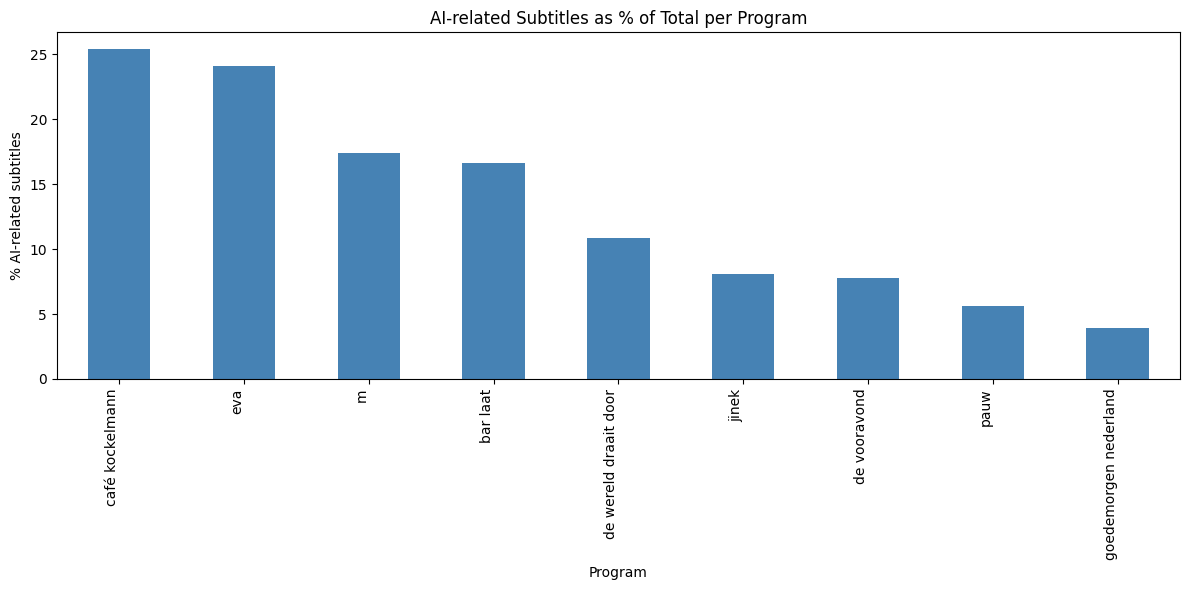

In [22]:
ratio = (ai_counts / total_counts * 100).sort_values(ascending=False)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
ratio.plot(kind='bar', color='steelblue')
# total_counts.plot(kind='line', marker='o', color='orange', label='Total subtitles')
# plt.legend(fontsize=8)  # smaller legend, with labels
plt.ylabel('% AI-related subtitles')
plt.xlabel('Program')
plt.title('AI-related Subtitles as % of Total per Program')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

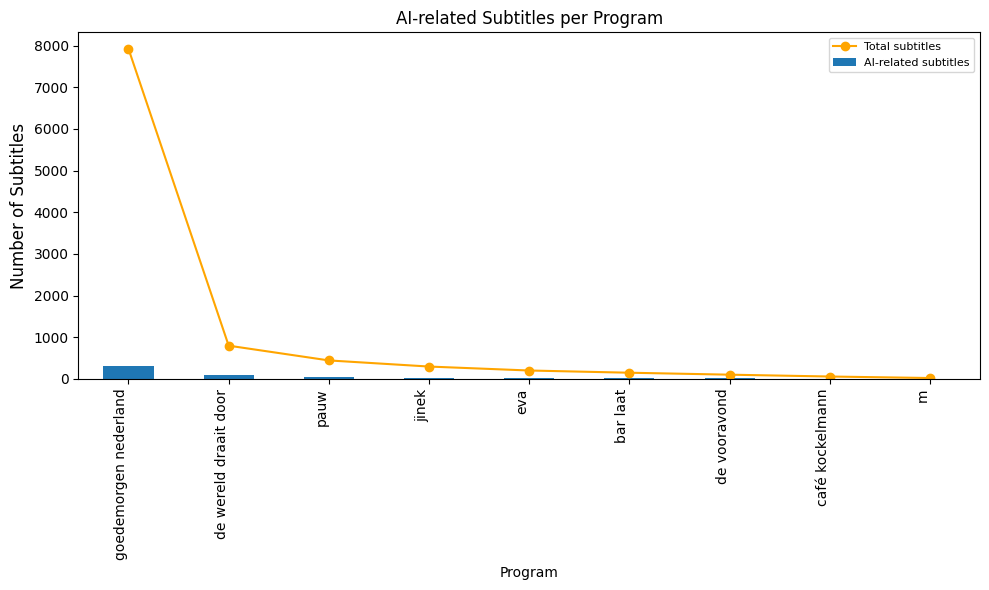

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
ai_counts.plot(kind='bar', label='AI-related subtitles')
total_counts.plot(kind='line', marker='o', color='orange', label='Total subtitles')
plt.xlabel('Program')
plt.ylabel('Number of Subtitles', size=12)
plt.title('AI-related Subtitles per Program')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.legend(fontsize=8)  # smaller legend, with labels
plt.tight_layout()
plt.show()

In [24]:
# # statistics on relevant sections

# # average length of relevant sections
# ai_related['relevant']

In [59]:
# save

ai_related.to_csv('subtitles_ai_related.csv')

In [27]:
classified_df.to_csv('subtitles_classified.csv')

In [11]:
classified_df = classified_df.drop(classified_df.columns[0], axis =1)

In [12]:
classified_df

,filename,program,year,text_clean,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
0,"2017-11-27-19,01-1",DE WERELD DRAAIT DOOR,2017,Goedenavond dit is De Wereld Draait Door van m...,no,[],[],[],0,0,[]
1,GOEDEMORGEN_N-WON02205666,Goedemorgen Nederland,2021,888\nWelkom terug bij Goedemorgen Nederland.\n...,no,[],[],[],0,0,[]
2,GOEDEMORGEN_N-WON02094879,Goedemorgen Nederland,2020,"888\nGoedemorgen Nederland, het is vandaag maa...",no,[],[],[],0,0,[twitter]
3,"2017-03-17-08,11-1",GOEDEMORGEN NEDERLAND,2017,Het grote schuiven is begonnen:\nWelke politie...,no,[],[],[],0,0,"[facebook, twitter]"
4,GOEDEMORGEN_N-WON02199391,Goedemorgen Nederland,2021,888\nWelkom terug bij Goedemorgen Nederland.\n...,no,[],[],[],0,0,[]
...,...,...,...,...,...,...,...,...,...,...,...
9995,"2016-01-27-07,40-1",GOEDEMORGEN NEDERLAND,2016,888\nGoedemorgen Nederland.\nBN'ers lezen vand...,no,[],[],[],0,0,[twitter]
9996,GOEDEMORGEN_N-WON02386562,Goedemorgen Nederland,2023,888\nGoedemorgen Nederland.\nNa het slotdebat ...,no,[],[],[],0,0,[]
9997,"2015-11-09-07,40-1",GOEDEMORGEN NEDERLAND,2015,888\nWe staan live bij het Openluchtmuseum in ...,no,[],[],[],0,0,[facebook]
9998,"2017-02-17-07,11-1",GOEDEMORGEN NEDERLAND,2017,Goedemorgen Nederland op deze vrijdagochtend.\...,no,[],[],[],0,0,[twitter]
